<a href="https://colab.research.google.com/github/MohammadYusif/time-series-forecasting-ai-systems/blob/main/day1/01_lab_decomposition.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

## Lab 1 — Decomposition & Autocorrelation

This lab is the hands-on companion to [Trend, Seasonality & Autocorrelation](01_decomposition_and_autocorrelation.qmd). It works with the `retail_demand.csv` golden-thread dataset (Riyadh/Grocery, daily units sold) to build the skill of *reading* a time series before modeling it: separating trend, seasonality, and what's left over, and checking whether a series is stationary — objective 1 of this course.

By the end you will have:

- decomposed a real (synthetic) demand series with STL and read what each component does and does not explain,
- read ACF/PACF plots on the raw and differenced series to spot candidate AR/MA structure,
- run the Augmented Dickey-Fuller test and interpreted its p-value in the right direction, and
- seen what a structural break looks like to a decomposition that has no way to know one happened.

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "statsmodels")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Locate rel_path from a repo checkout (tries rel_path and ../rel_path
    — labs live one directory below the repo root) or download it from
    GitHub if neither exists (a fresh Colab runtime)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mape, smape, wape, mase, pinball_loss, coverage, interval_width

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)


### Load the golden-thread series

`data/retail_demand.csv` is long-format across 3 regions x 2 categories. By convention this course sticks to the Riyadh/Grocery series for Day 1 and Day 2 so the same numbers recur lesson to lesson. We give it an explicit daily `DatetimeIndex` with `.asfreq("D")` — this is what lets `statsmodels` reason about lags in calendar terms rather than just row position, and it will loudly surface any missing date as a `NaN` rather than silently shifting everything after it.

2023-01-01 00:00:00 to 2025-12-31 00:00:00 - 1096 days
0 missing days after asfreq


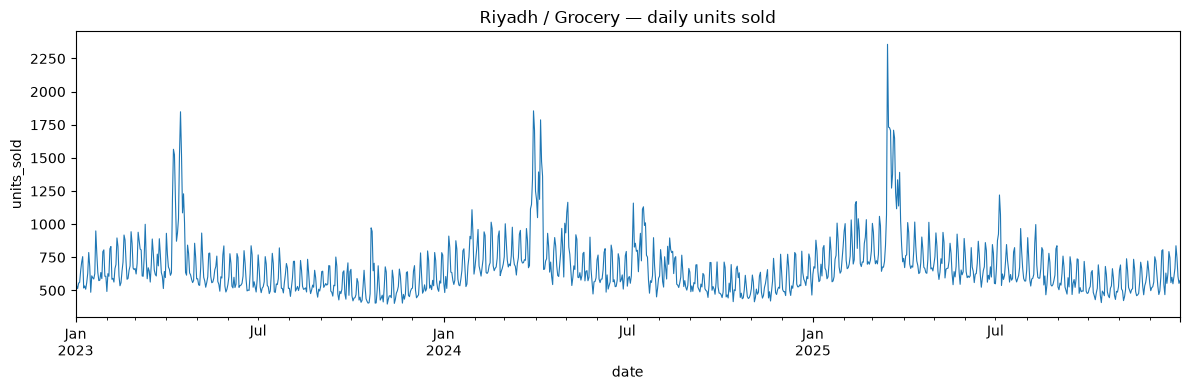

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
riyadh_grocery = df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")].copy()
riyadh_grocery = riyadh_grocery.set_index("date")["units_sold"].asfreq("D")

print(riyadh_grocery.index.min(), "to", riyadh_grocery.index.max(), "-", len(riyadh_grocery), "days")
print(riyadh_grocery.isna().sum(), "missing days after asfreq")

fig, ax = plt.subplots(figsize=(12, 4))
riyadh_grocery.plot(ax=ax, linewidth=0.8)
ax.set_title("Riyadh / Grocery — daily units sold")
ax.set_ylabel("units_sold")
plt.tight_layout()
plt.show()


### STL decomposition

`STL` (Seasonal-Trend decomposition using LOESS) splits the series into `observed = trend + seasonal + residual`. We use `period=7` for weekly seasonality (daily data) and `robust=True` so a handful of promo-shock outlier days don't distort the trend/seasonal fit.

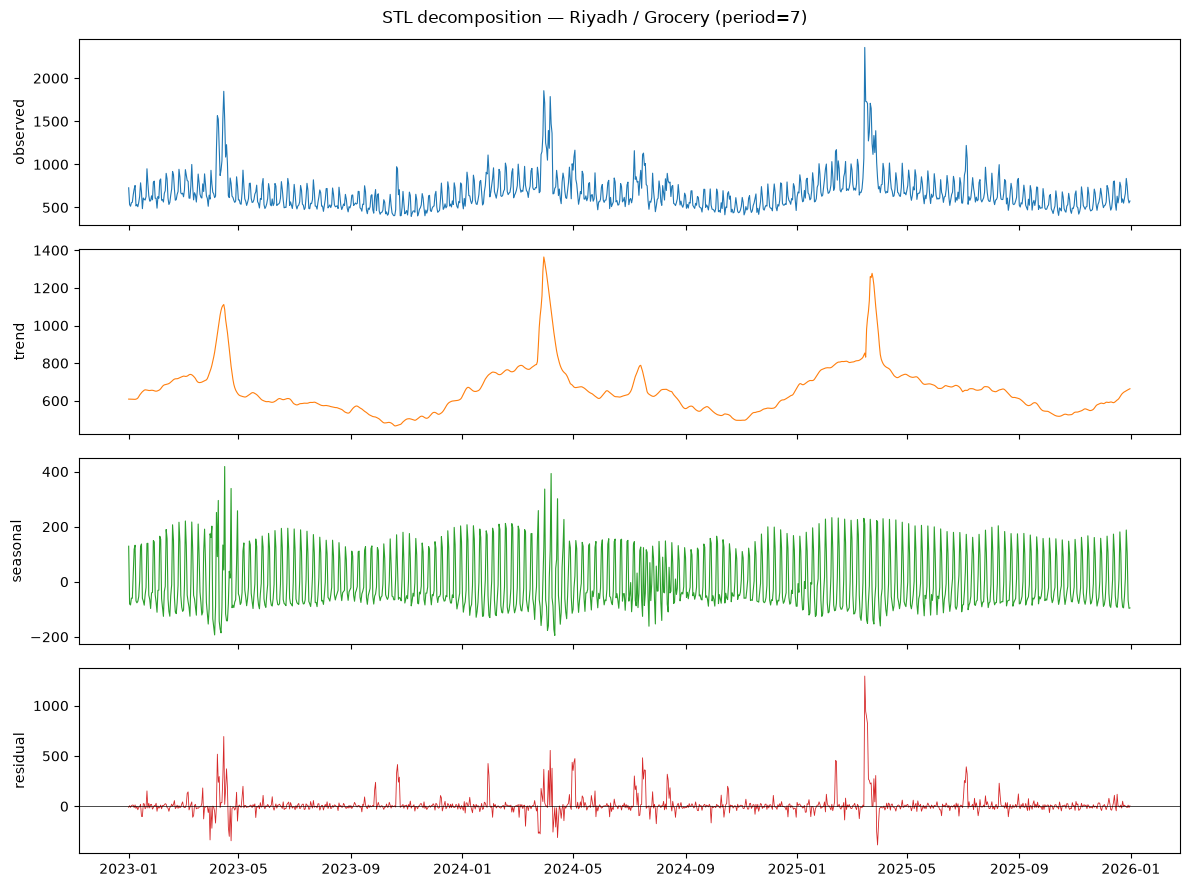

residual std: 104.68739531431726
largest 5 |residual| days:
date
2025-03-16    1293.844161
2025-03-17     942.499865
2025-03-18     885.541233
2025-03-19     819.675148
2023-04-15     693.547435
Name: resid, dtype: float64


In [3]:
from statsmodels.tsa.seasonal import STL

stl = STL(riyadh_grocery, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(riyadh_grocery.index, riyadh_grocery.values, linewidth=0.8)
axes[0].set_ylabel("observed")
axes[1].plot(riyadh_grocery.index, result.trend, linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("trend")
axes[2].plot(riyadh_grocery.index, result.seasonal, linewidth=0.8, color="tab:green")
axes[2].set_ylabel("seasonal")
axes[3].plot(riyadh_grocery.index, result.resid, linewidth=0.6, color="tab:red")
axes[3].set_ylabel("residual")
axes[3].axhline(0, color="black", linewidth=0.5)
fig.suptitle("STL decomposition — Riyadh / Grocery (period=7)")
plt.tight_layout()
plt.show()

print("residual std:", np.std(result.resid))
print("largest 5 |residual| days:")
print(result.resid.abs().sort_values(ascending=False).head(5))


### Reading the decomposition

A few things to look for once you've run the cell above (fill these in from
your own plot, but here is what to expect from this series):

- **Trend** climbs gently but unevenly over the three years — grocery demand
  in this synthetic series is drifting up, not flat.
- **Seasonal** is a clean, repeating 7-day sawtooth: the weekend lift (Fri/Sat
  in a Riyadh calendar) shows up as the same shape every single week, because
  STL with `period=7` forces the seasonal component to repeat exactly.
- **Residual** is where the interesting failure shows up. STL's seasonal
  component is *one fixed weekly shape repeated forever* — it cannot
  represent a demand bump that only happens a few times a year (a
  holiday-style surge) or a short 2-4 day promo shock. Both of those are
  built into `retail_demand.csv`'s generator, and neither is "seasonality"
  in the period-7 sense, so STL correctly leaves them in the residual. Look
  at `result.resid.abs().sort_values(ascending=False).head(5)` above — the
  largest residual days should cluster around specific short windows rather
  than being spread evenly across the three years. That clustering is the
  promo shocks and holiday bumps STL couldn't absorb, sitting exactly where
  a real analyst would want to go look at what happened on those dates.

This is a general lesson, not just a quirk of this dataset: STL (or any
fixed-period decomposition) separates *regular* seasonality from everything
else. Irregular events — holidays that move date every year, promotions,
one-off shocks — always end up in the residual. That is not a bug in STL;
it is a reason to model those events explicitly (e.g. as exogenous regressors,
covered when we get to feature engineering on Day 2) rather than expecting a
seasonal decomposition to explain them away.


### ACF and PACF — raw vs. differenced

The autocorrelation function (ACF) measures how correlated the series is with itself at each lag; the partial autocorrelation function (PACF) measures the same thing after removing the effect of the shorter lags in between. Reading both together is how you propose a starting ARIMA order before letting AIC/BIC pick between candidates in the next lesson.

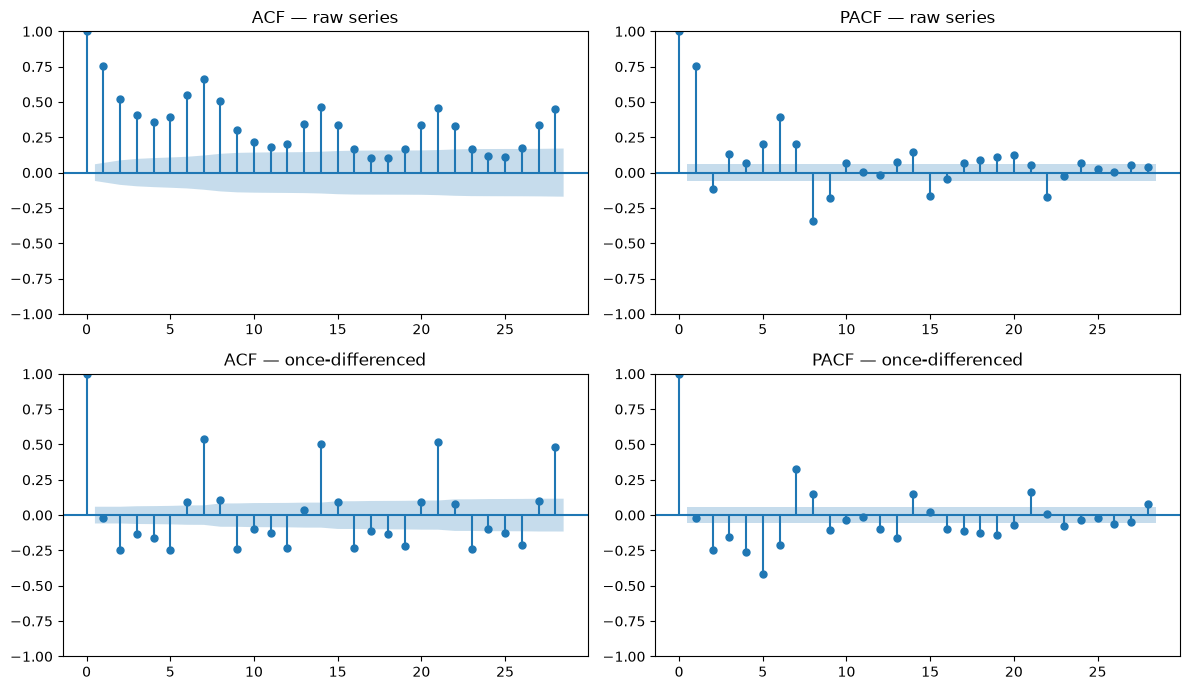

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diffed = riyadh_grocery.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(riyadh_grocery, lags=28, ax=axes[0, 0])
axes[0, 0].set_title("ACF — raw series")
plot_pacf(riyadh_grocery, lags=28, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — raw series")
plot_acf(diffed, lags=28, ax=axes[1, 0])
axes[1, 0].set_title("ACF — once-differenced")
plot_pacf(diffed, lags=28, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — once-differenced")
plt.tight_layout()
plt.show()


### Reading the ACF/PACF plots

**Raw series (top row):** the ACF decays very slowly and shows spikes at lag
7, 14, 21, 28 — the classic signature of both a trend (slow overall decay,
because today looks like yesterday looks like the day before) and weekly
seasonality (the periodic spikes on multiples of 7). A slowly-decaying ACF
like this is itself evidence the series is non-stationary — its mean/level
is drifting, so correlation with the past doesn't die off with distance the
way it would for a stationary series. The PACF on the raw series typically
shows one dominant spike at lag 1 and then much smaller values, which is
what you'd expect when most of the raw autocorrelation is actually being
driven by the trend rather than a rich autoregressive structure.

**Once-differenced (bottom row):** differencing removes the trend, and the
slow decay in the ACF should be mostly gone — what's left is short-lived
autocorrelation plus the lag-7 seasonal spikes that differencing (which is
a plain lag-1 difference here, not a seasonal difference) doesn't touch. The
lag-7-and-multiples spikes persisting after a single difference are the
reason Day 1's next lesson reaches for **seasonal** ARIMA (SARIMA) rather
than plain ARIMA on this data — a non-seasonal difference alone doesn't
remove weekly seasonality.

**What this suggests for model order:** a sharp PACF cutoff after lag `p`
with a tailing-off ACF suggests an AR(`p`) term; a sharp ACF cutoff after
lag `q` with a tailing PACF suggests an MA(`q`) term. The persistent lag-7
spikes in both plots are the signal for a seasonal AR/MA term at `s=7` —
exactly the `(P, D, Q)_7` half of the SARIMA order chosen in the next
lesson (`day1/02_classical_models.qmd`).


### Augmented Dickey-Fuller (ADF) test

A formal stationarity test to check what the ACF's slow decay already suggested about the raw series, and confirm what differencing fixed.

In [5]:
from statsmodels.tsa.stattools import adfuller

def report_adf(series, label):
    # result_object=True: the tuple-unpacking return is deprecated in
    # statsmodels 0.15+ (removed in 0.16 / after July 2027) in favor of a
    # named ADFullerResult -- see statsmodels release notes.
    result = adfuller(series.dropna(), autolag="AIC", result_object=True)
    print(f"{label}")
    print(f"  ADF statistic: {result.statistic:.4f}")
    print(f"  p-value:       {result.pvalue:.6f}")
    print(f"  used lags:     {result.lags}")
    for level, cv in result.critical_values.items():
        print(f"  critical value ({level}): {cv:.4f}")
    verdict = "stationary (reject the unit-root null)" if result.pvalue < 0.05 else "NON-stationary (fail to reject the unit-root null)"
    print(f"  => {verdict}\n")
    return result.pvalue

pvalue_raw = report_adf(riyadh_grocery, "Raw series")
pvalue_diff = report_adf(diffed, "Once-differenced series")


Raw series
  ADF statistic: -3.8721
  p-value:       0.002250
  used lags:     21
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)

Once-differenced series
  ADF statistic: -9.8473
  p-value:       0.000000
  used lags:     22
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)



### Interpreting the ADF test — get the direction right

The ADF null hypothesis is **"this series has a unit root"** (i.e. it is
non-stationary). That means:

- **Low p-value (< 0.05) → reject the null → the series IS stationary.**
- **High p-value (>= 0.05) → fail to reject the null → the series is NOT
  (necessarily) stationary.**

This direction is the single most commonly inverted stat-test result in
practice — it is easy to instinctively read "low p-value" as "bad news"
the way you might for a null of "no effect," but here the null is the
undesirable state (non-stationarity), so a low p-value is the *good* result
if what you want is a stationary series to feed into ARIMA.

**What actually happened here is worth sitting with rather than glossing
over.** Both the raw series (p ≈ 0.0023) and the once-differenced series
(p ≈ 0.0000) reject the unit-root null — ADF calls *both* "stationary,"
even though the raw series' plot climbs visibly over three years and the
STL trend component confirms a real upward drift. That is not a
contradiction; it's a reminder of exactly what this test checks. Called as
`adfuller(series, autolag="AIC")`, it defaults to `regression="c"` — a unit
root tested against a constant mean, not against a deterministic trend. A
*stochastic* unit root (a random walk) has ever-growing variance and no
tendency to return to any baseline; this series has neither symptom, trend
or no trend, because the weekly seasonal cycle pulls it back toward a
(slowly moving) baseline every few days. ADF is answering "does this series
wander off with no anchor," not "is the level flat" — and the answer here is
no, it doesn't wander, on both the raw and differenced series.

Two practical takeaways: (1) check what `regression=` an ADF call is
actually using before reading "stationary" as "no trend at all" — pass
`regression="ct"` when a deterministic trend is what you actually want to
test against; and (2) a hypothesis test is one input, not the whole
decision. The visible trend and the raw series' slowly-decaying ACF (from
the previous section) are still real reasons to consider differencing when
choosing an ARIMA order next lesson, even though this particular test
already accepted the raw series as stationary by its own (narrower)
definition.


## Second pass — `workforce_demand.csv` and a structural break

Everything above assumes the series' underlying process is stable across the whole window being decomposed. `data/workforce_demand.csv` breaks that assumption on purpose: required headcount jumps by roughly 35% starting 2025-04-01 and stays there. Let's decompose it the same way and see what a decomposition that has no concept of "the rules changed on this date" actually does with that.

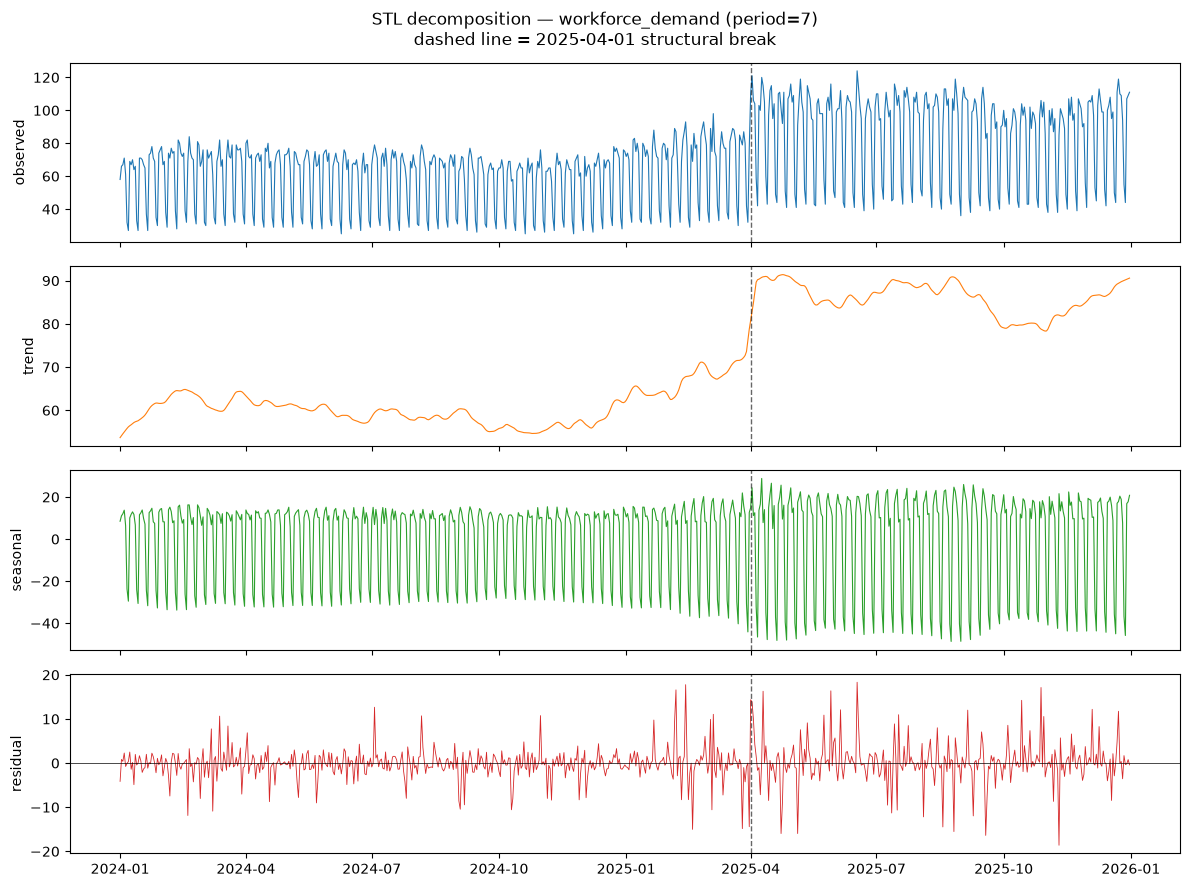

Residual mean before 2025-04-01: -0.2041008433188911
Residual mean 2025-04-01 to 2025-05-15: 0.5059362335314129


In [6]:
workforce = pd.read_csv(fetch("data/workforce_demand.csv"), parse_dates=["date"])
workforce = workforce.set_index("date")["required_headcount"].asfreq("D")

stl_wf = STL(workforce, period=7, robust=True)
result_wf = stl_wf.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(workforce.index, workforce.values, linewidth=0.8)
axes[0].set_ylabel("observed")
axes[1].plot(workforce.index, result_wf.trend, linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("trend")
axes[2].plot(workforce.index, result_wf.seasonal, linewidth=0.8, color="tab:green")
axes[2].set_ylabel("seasonal")
axes[3].plot(workforce.index, result_wf.resid, linewidth=0.6, color="tab:red")
axes[3].set_ylabel("residual")
axes[3].axhline(0, color="black", linewidth=0.5)
for ax in axes:
    ax.axvline(pd.Timestamp("2025-04-01"), color="black", linestyle="--", linewidth=1, alpha=0.6)
fig.suptitle("STL decomposition — workforce_demand (period=7)\ndashed line = 2025-04-01 structural break")
plt.tight_layout()
plt.show()

window = result_wf.resid.loc["2025-03-01":"2025-05-15"]
print("Residual mean before 2025-04-01:", result_wf.resid.loc[:"2025-03-31"].mean())
print("Residual mean 2025-04-01 to 2025-05-15:", result_wf.resid.loc["2025-04-01":"2025-05-15"].mean())


### The structural break STL can't see coming

`workforce_demand.csv` has a sustained ~35% step-change in required
headcount starting 2025-04-01 — a regime shift, not a gradual trend. STL
(and ACF/PACF, and the ADF test) all assume the seasonal pattern and the
underlying level are drawn from a single stable process across the whole
window they're fit on. None of them "know about" a date where that stops
being true.

Look at the residual mean printed above: it should sit close to zero for
the months before 2025-04-01, then jump to a clearly nonzero value in the
weeks right after it. That is STL's trend component being too smooth to
snap to a sudden step, so the actual step gets dumped into the residual
right at the break — a visible, measurable symptom of "this decomposition's
assumptions just broke," not a subtle statistical artifact.

The practical takeaway for forecasting (not just decomposition): a model
backtested entirely on data from before a structural break will look
excellent in validation and then be wrong by a predictable, sustained
amount the moment the regime actually shifts. Day 3's model-comparison
lesson returns to this exact series to make that failure concrete.


## What carries into Lab 2

Three things from this lab feed directly into the next one
(`day1/02_lab_arima_ets.ipynb`):

1. **`d` is a judgment call, not a single test's verdict.** ADF alone
   accepted the raw Riyadh/Grocery series as stationary (its default form
   tests against a constant, not a trend) — but the visible trend, the
   STL trend component, and the raw ACF's slow decay all point the other
   way. Lab 2's order search still evaluates `d=1` as a candidate and lets
   AIC/BIC and residual diagnostics settle it, rather than trusting one
   test's p-value on its own.
2. **The ACF/PACF read suggests `p`/`q`, and the lag-7 spikes that survive
   differencing are the case for a seasonal term.** Lab 2 fits both a plain
   ARIMA and a seasonal SARIMA on the same series and compares them with
   AIC/BIC and residual diagnostics (Ljung-Box) — the order search there
   starts from exactly the candidate orders this lab's plots pointed at.
3. **STL residuals that don't look like noise are a diagnostic, not just a
   picture.** The same idea — "does what's left over look structured or does
   it look like noise?" — is what Ljung-Box formalizes for a fitted model's
   residuals in the next lesson.

Continue to the next lesson: [Classical Forecasting Models](02_classical_models.qmd)
